# Gene expression analysis

In [29]:
# Load packages
suppressPackageStartupMessages({
    library(ggplot2)
    library(biomaRt)
    library(BiocParallel)
    library(Matrix)
    library(matrixStats)
    library(scater)
    library(reshape2)
    library(knitr)
    library(scran)
    library(batchelor)
    library(reticulate)
    library(SingleCellExperiment)
    library(data.table)
    library(dplyr)
    library(gridExtra)
    library(viridis)
})
    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)
    BPPARAM = SerialParam()

options(repr.plot.width=15, repr.plot.height=8)

In [2]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/"
mapping_dir = paste0(main, '07_atlas_mapping/')
out_dir = paste0(main, '09_gene_expression_analysis/')
dir.create(out_dir, showWarnings = FALSE)

source(paste0(main, "core_functions.R"))

In [3]:
umap_theme =  theme(text = element_text(size = 30),
                axis.text.y   = element_blank(),
                axis.text.x   = element_blank(),
                axis.title.y  = element_blank(),
                axis.title.x  = element_blank(),
                axis.ticks = element_blank(),
                legend.position = "none",
                panel.background = element_blank(),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.border = element_rect(colour = "black", fill=NA, size=1))

In [14]:
load_data(remove_doublets = TRUE, remove_stripped = TRUE)

In [15]:
big_meta = read.csv(paste0(mapping_dir, 'big_meta_complete.csv'))
big_meta = big_meta[big_meta$exp=='eomes', c('cell', 'celltype.mapped', 'stage.mapped')]
big_meta$cell = paste0('cell_', sapply(strsplit(big_meta$cell,"_"), `[`, 3))
meta = merge(meta, big_meta, by='cell', all.x=TRUE)
meta = meta[order(meta$index),]
rm(big_meta)

In [19]:
meta$umap_1 = as.numeric(meta$umap_1)
meta$umap_2 = as.numeric(meta$umap_2)

In [20]:
head(meta,2)

,cell,barcode,stage,batch,Sample_name,batch_name,tdTom,sample,doub.density,doublet,stripped,index,umap_1,umap_2,louvain_cluster,celltype.mapped,stage.mapped
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<lgl>,<lgl>,<int>,<dbl>,<dbl>,<int>,<chr>,<chr>
1,cell_1,AAACCCAGTTCTCTAT,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,13.9251218125,FALSE,FALSE,1,-0.6908035,3.695314,11,Rostral neurectoderm,E8.0
10638,cell_2,AAACGCTAGTGATTCC,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,17.2720353798127,FALSE,FALSE,2,6.8198771,10.802951,7,Intermediate mesoderm,E8.0


In [63]:
# download gene names
mouse_ensembl = useMart("ensembl")
mouse_ensembl = useDataset("mmusculus_gene_ensembl", mart = mouse_ensembl)
gene_map = getBM(attributes=c("ensembl_gene_id", "external_gene_name"), values = genes, mart = mouse_ensembl)


Ensembl site unresponsive, trying useast mirror



ERROR: Error in curl::curl_fetch_memory(url, handle = handle): SSL certificate problem: unable to get local issuer certificate


In [ ]:
# convert gene id to gene name
genes = data.frame('ensembl_gene_id'= names(sce))
genes = merge(genes, gene_map, by='ensembl_gene_id', all.x=TRUE)
genes$external_gene_name[is.na(genes$external_gene_name)] = genes$ensembl_gene_id[is.na(genes$external_gene_name)]

In [66]:
# use gene names in sce object
names(sce) = genes$external_gene_name

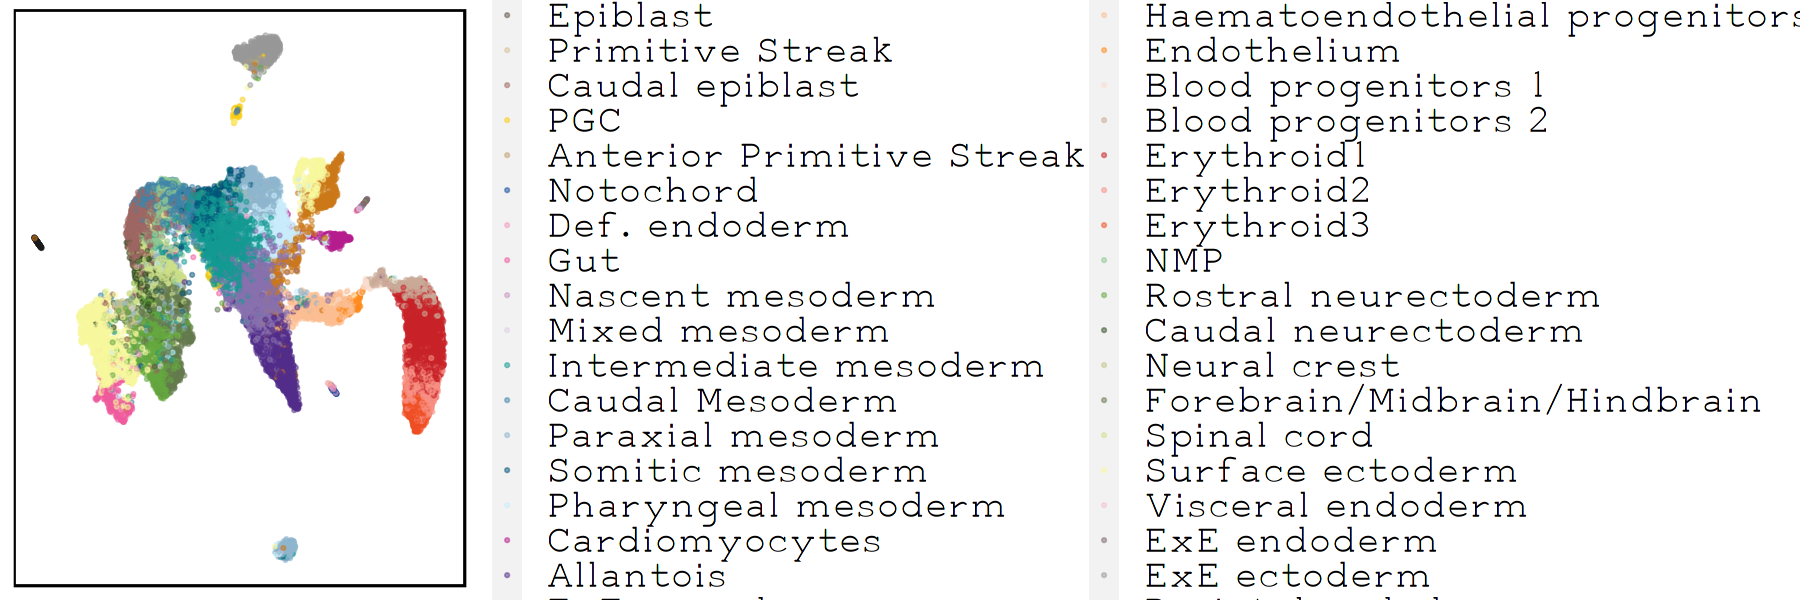

In [158]:
ggplot(meta, aes(umap_1, umap_2, col=celltype.mapped)) + 
        geom_point(size = 0.7, alpha = 0.5) + 
    scale_colour_manual(values = celltype_colours,  name = "celltype") +
        umap_theme + theme(legend.position = "right")

In [77]:
WT = meta[meta$tdTom=='negative',]$cell

In [109]:
WT = meta[meta$tdTom=='negative',]
KO = meta[meta$tdTom!='negative',]

plot_gene = function(x){

    p1 = ggplot(WT, aes(umap_1, umap_2, col=as.vector(logcounts(sce[x,cell])))) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_color_viridis() + 
        ggtitle(paste0('log expression ', names(sce[x,]))) +
        umap_theme
    p2 = ggplot(KO, aes(umap_1, umap_2, col=as.vector(logcounts(sce[x,cell])))) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_color_viridis() + 
        ggtitle(paste0('log expression ', names(sce[x,]))) +
        umap_theme
    grid.arrange(p1, p2, ncol=2)
}

In [144]:
HVGs = getHVGs(sce)

Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”


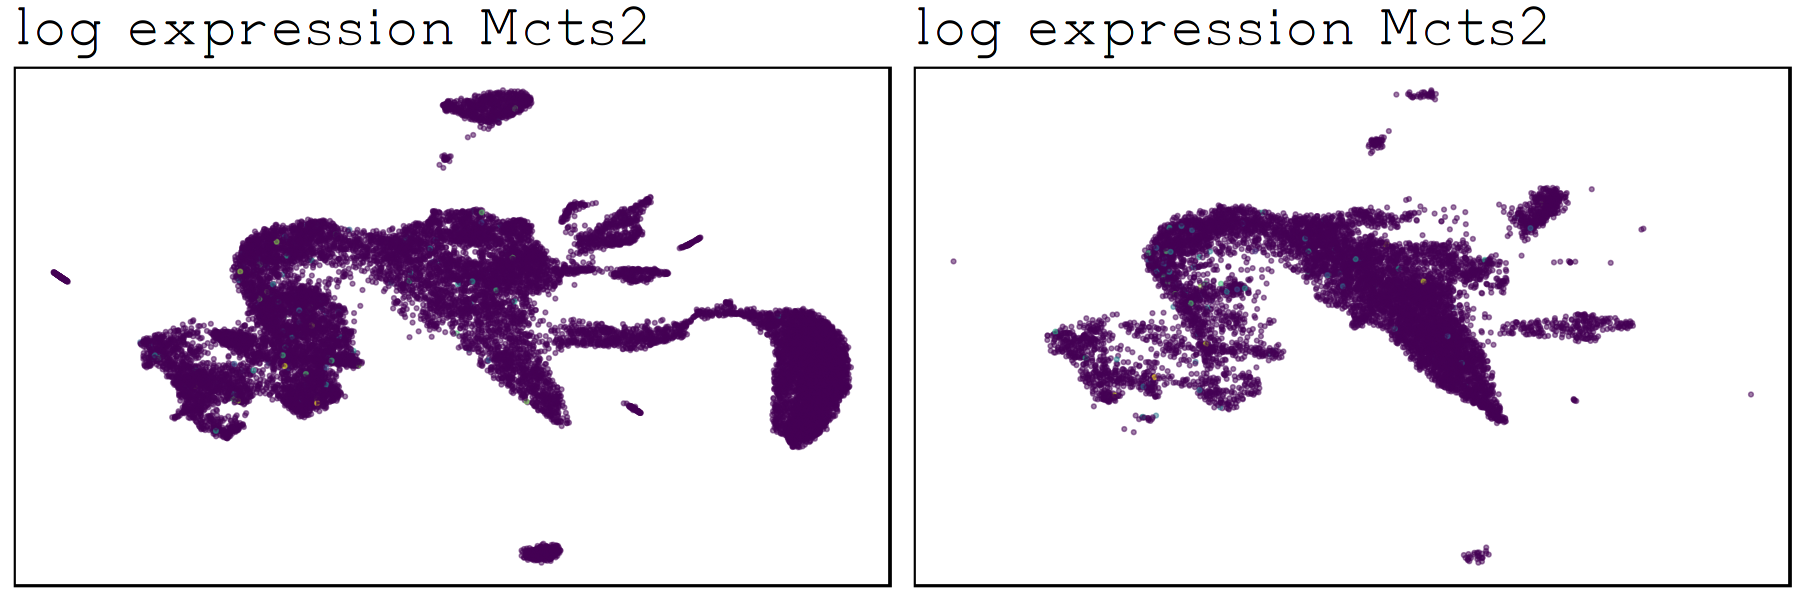

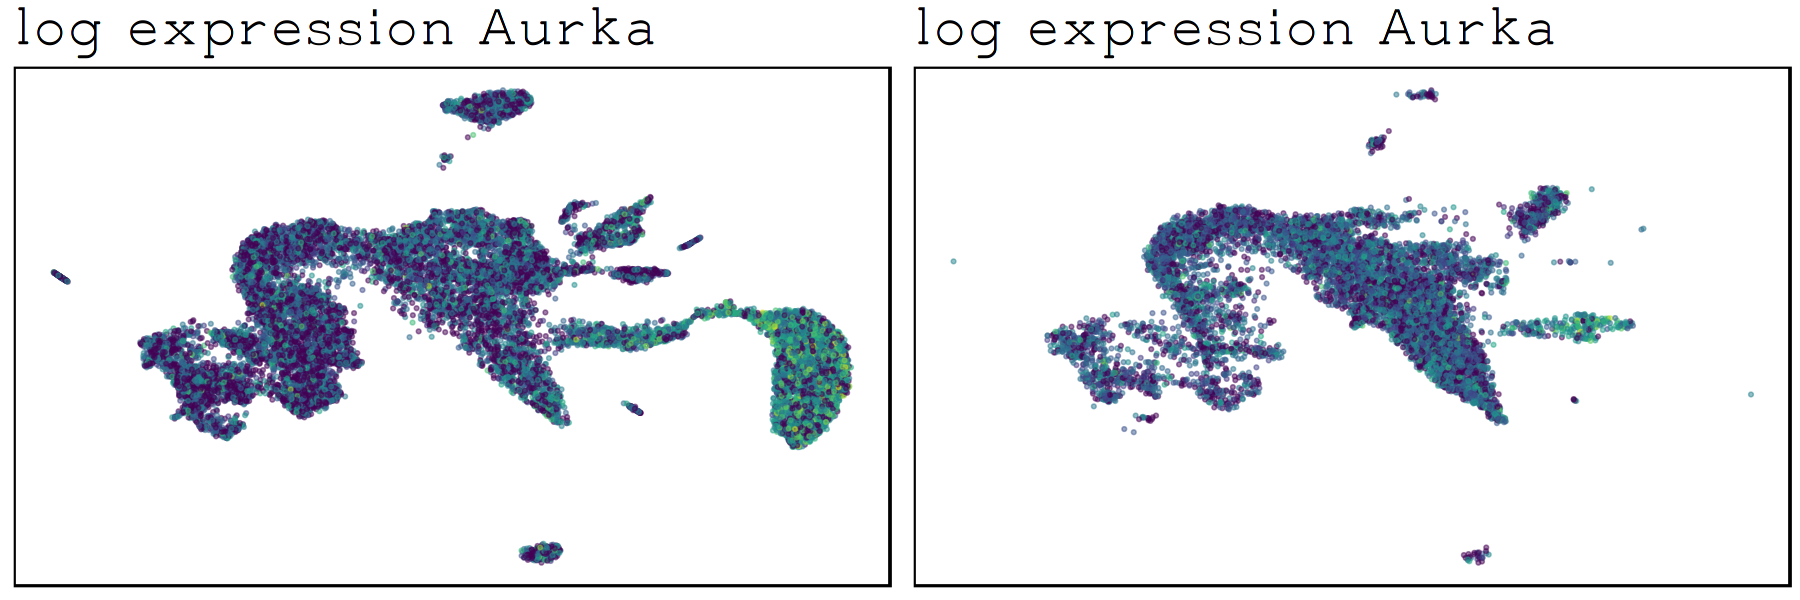

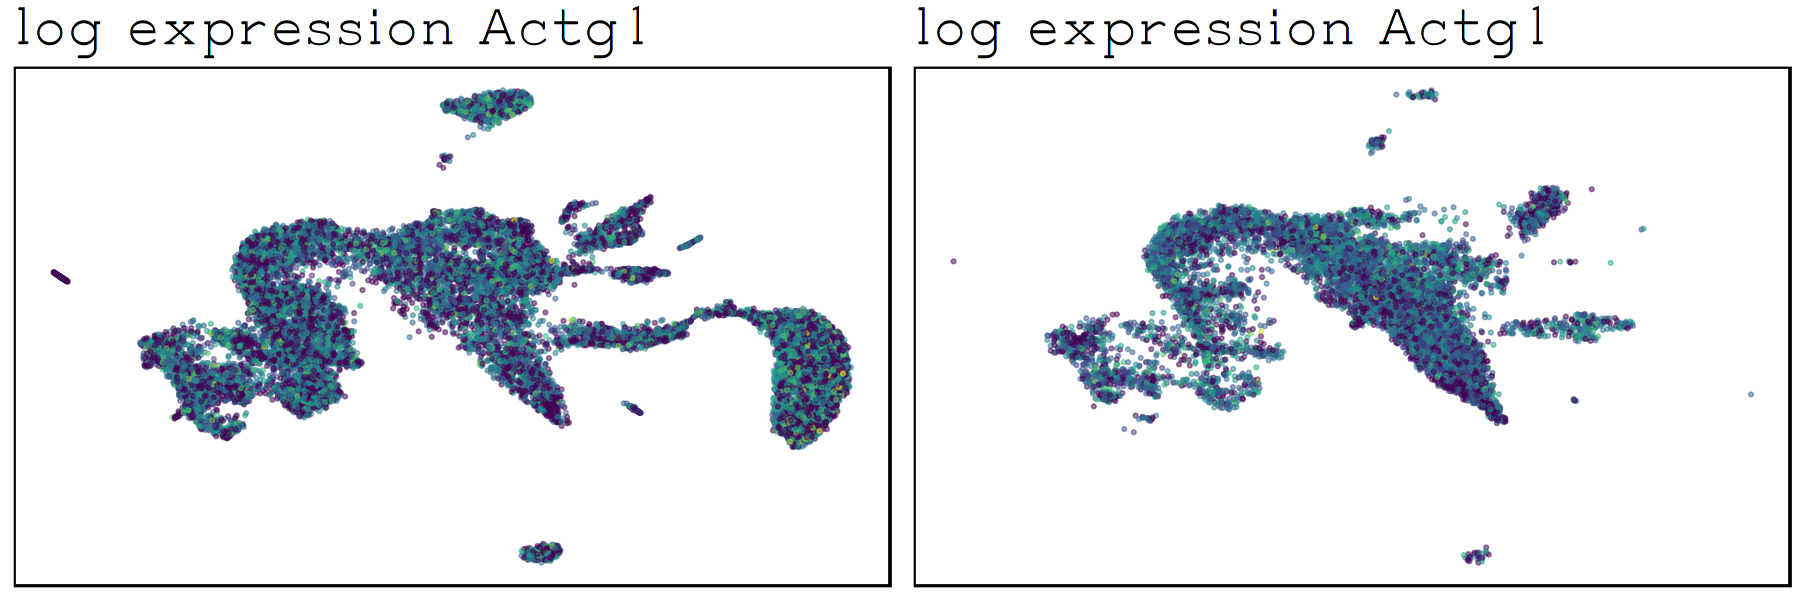

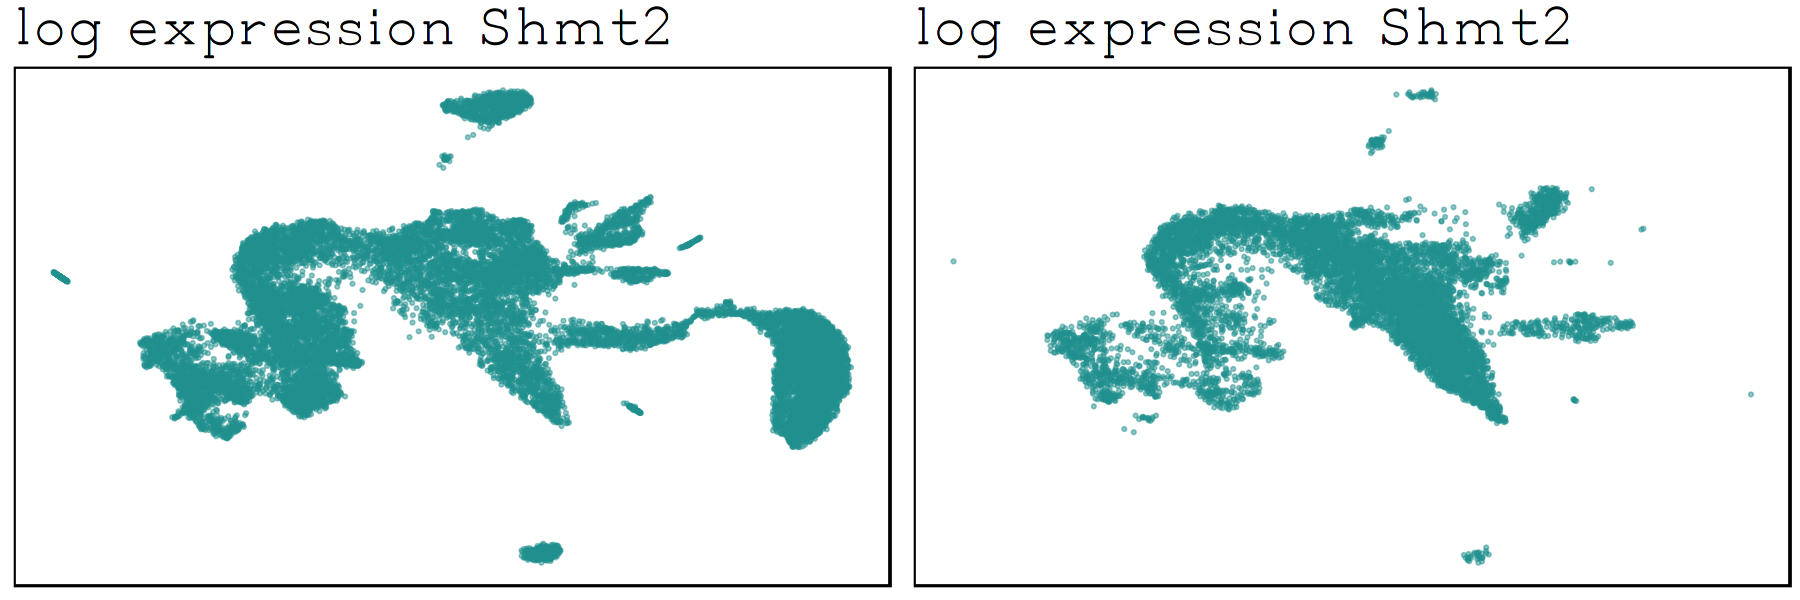

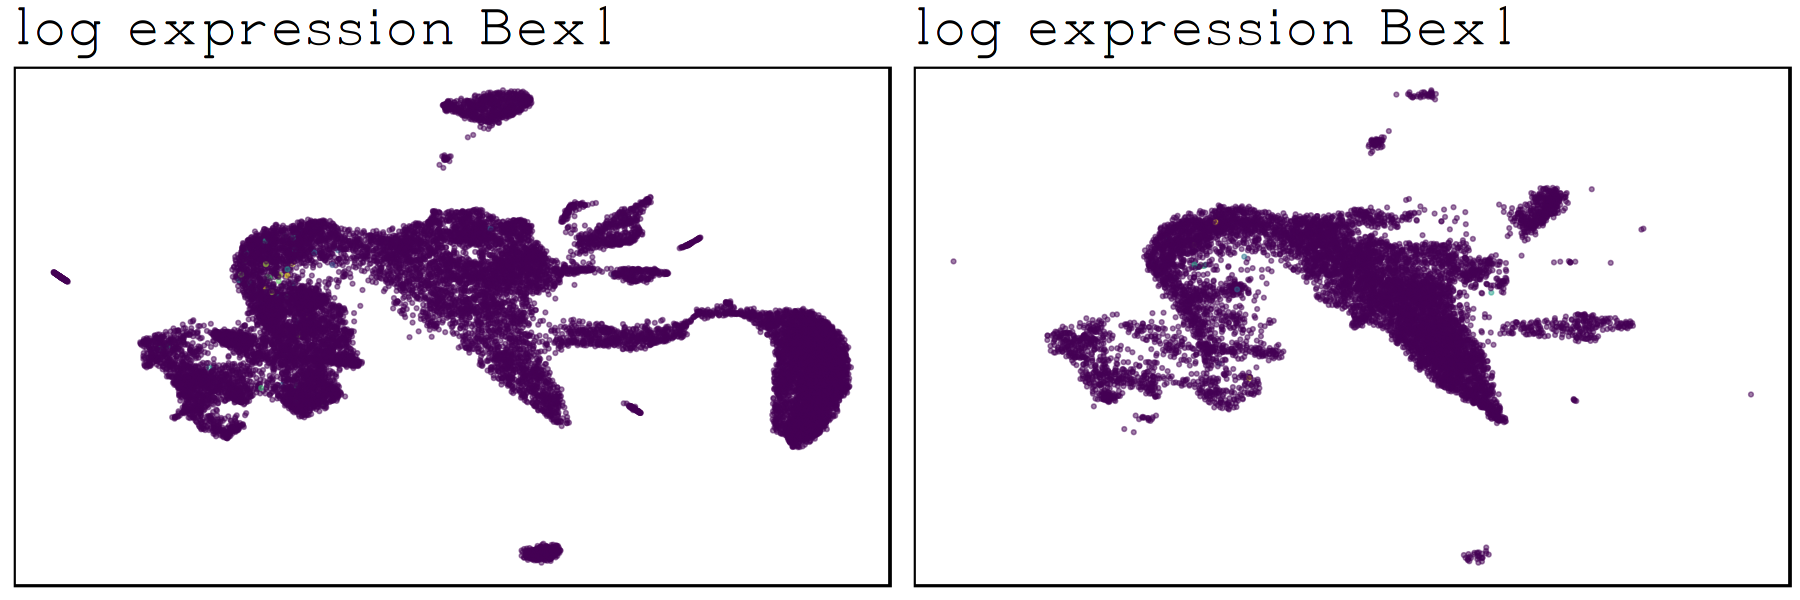

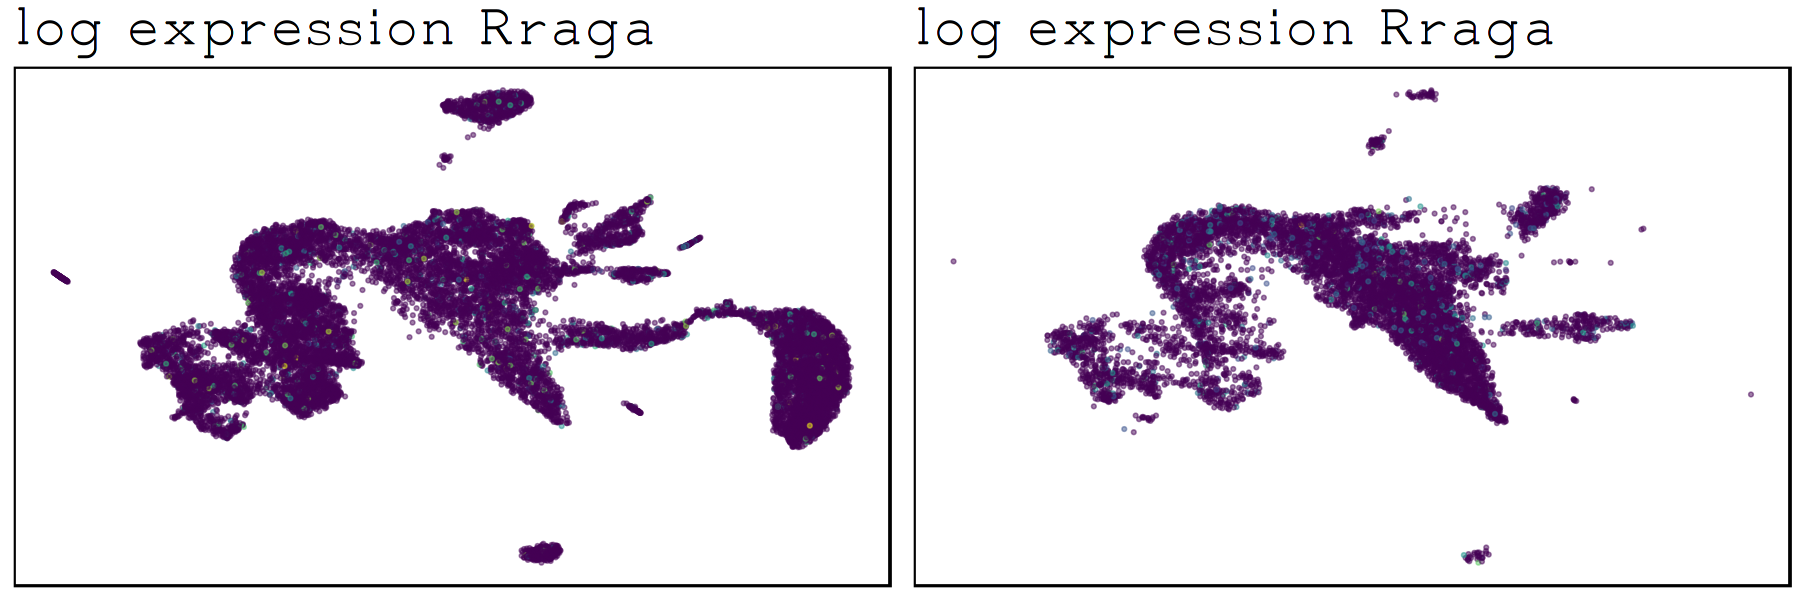

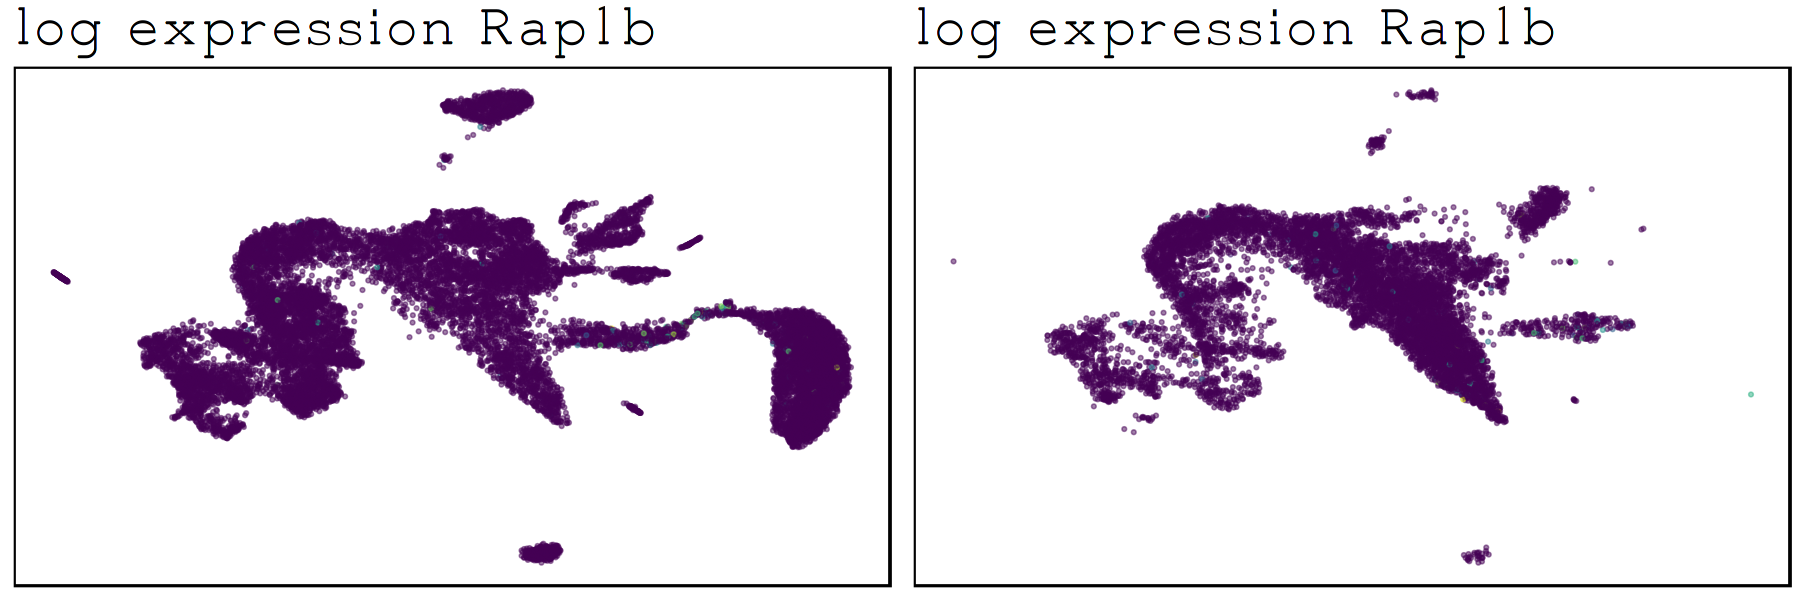

In [151]:
genes = c('Mcts2', 'Aurka', 'Actg1', 'Shmt2', 'Bex1', 'Rraga', 'Rap1b')
options(repr.plot.width=15, repr.plot.height=5)
plots = lapply(genes, plot_gene)